In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/Heart.csv")

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [ ]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    int64  
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    object 
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    object 
 14  AHD         303 non-null    object 
dtypes: float64(2), int64(10), object(3)
memory usage: 35.6+ KB
Unnamed: 0    0
Age           0
Sex           0
ChestPain     0
RestBP        0
Chol          0
Fbs           0
RestECG       0
MaxHR 

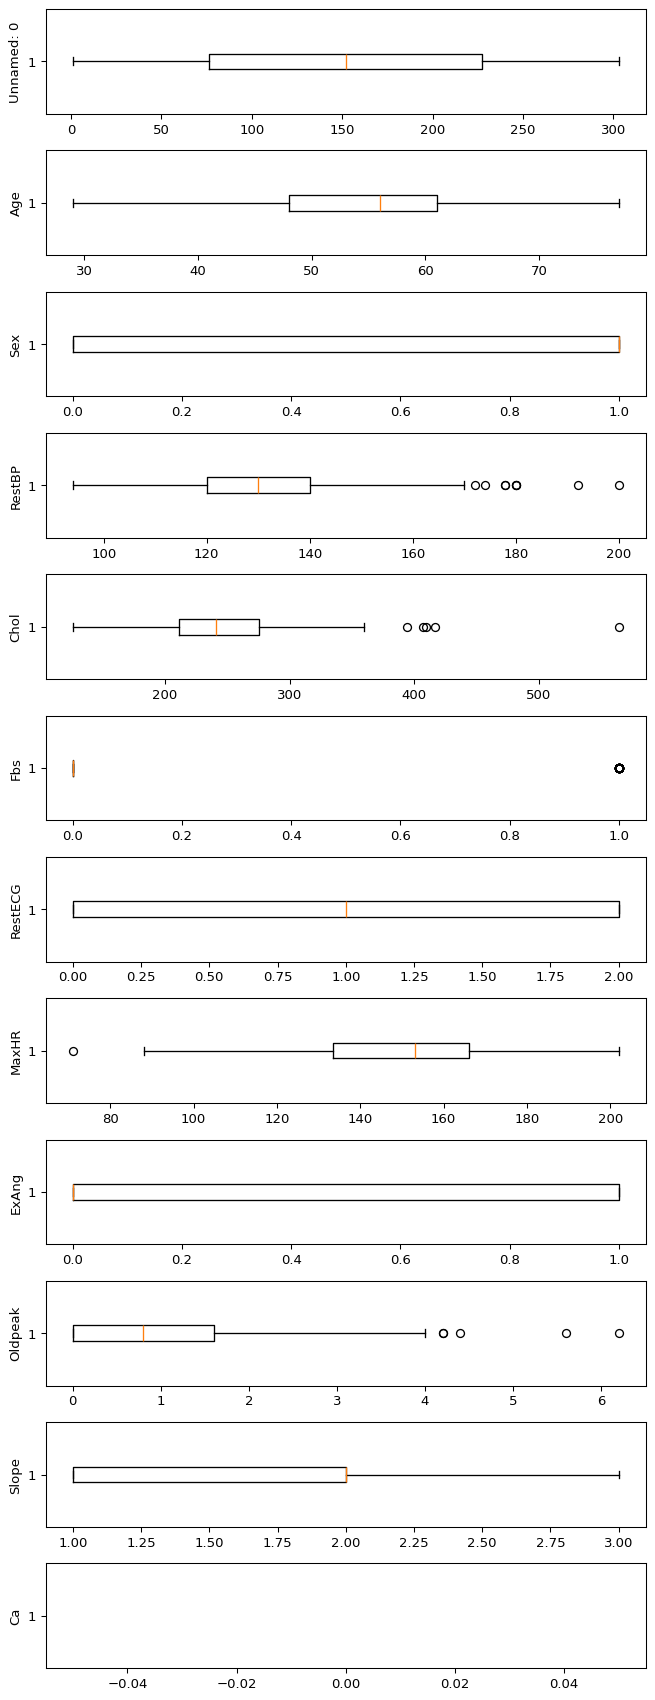

In [ ]:
import matplotlib.pyplot as plt

df.describe()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
fig, axs = plt.subplots(len(num_cols), 1, figsize=(7, 18), dpi=95)

for i, col in enumerate(num_cols):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()


In [ ]:
q1,q3 = np.percentile(df['Chol'],[25,75])
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
clean_df=df[(df['Chol']>=lower)&(df['Chol']<=upper)]

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])


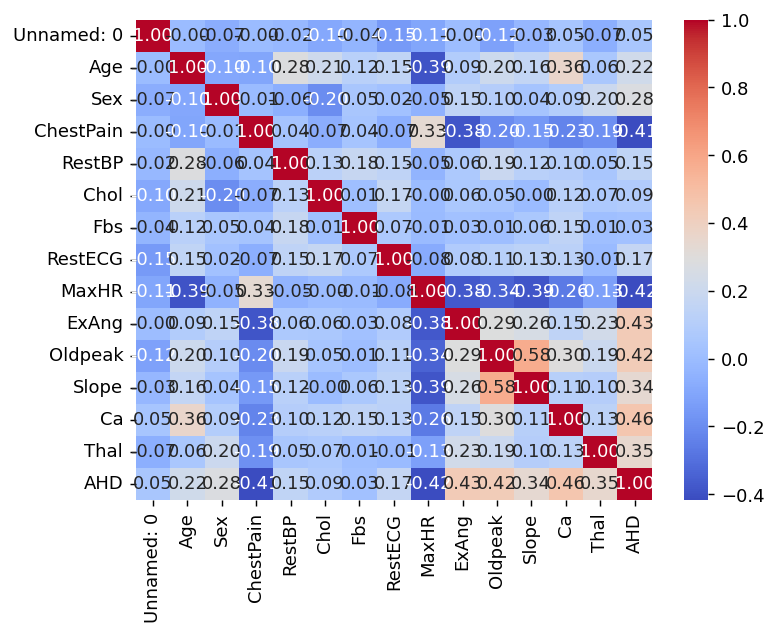

AHD           1.000000
Ca            0.460442
ExAng         0.431894
Oldpeak       0.424510
Thal          0.352240
Slope         0.339213
Sex           0.276816
Age           0.223120
RestECG       0.169202
RestBP        0.150825
Chol          0.085164
Unnamed: 0    0.048765
Fbs           0.025264
ChestPain    -0.414446
MaxHR        -0.417167
Name: AHD, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr()

plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['AHD'].sort_values(ascending=False))


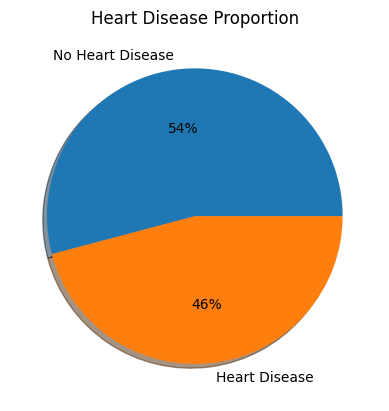

In [ ]:
plt.pie(
    df['AHD'].value_counts(),
    labels=['No Heart Disease', 'Heart Disease'],
    autopct='%.f%%',
    shadow=True
)
plt.title('Heart Disease Proportion')
plt.show()


In [ ]:
X = df.drop(columns=['AHD'])
Y = df['AHD']

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_encoded)

print(X_normalized[:5])


[[0.         0.70833333 1.         1.         0.48113208 0.24429224
  1.         1.         0.60305344 0.         0.37096774 1.
  0.         0.        ]
 [0.00331126 0.79166667 1.         0.         0.62264151 0.3652968
  0.         1.         0.28244275 1.         0.24193548 0.5
  1.         0.33333333]
 [0.00662252 0.79166667 1.         0.         0.24528302 0.23515982
  0.         1.         0.44274809 1.         0.41935484 0.5
  0.66666667 0.66666667]
 [0.00993377 0.16666667 1.         0.33333333 0.33962264 0.28310502
  0.         0.         0.88549618 0.         0.56451613 1.
  0.         0.33333333]
 [0.01324503 0.25       0.         0.66666667 0.33962264 0.17808219
  0.         1.         0.77099237 0.         0.22580645 0.
  0.         0.33333333]]


In [ ]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

for col in X_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_encoded)

print(X_standardized[:5])


[[-1.72634387  0.94872647  0.68620244  2.25177456  0.75752504 -0.2649003
   2.394438    1.01668424  0.01719733 -0.69663055  1.08733806  2.27457861
  -0.71830622 -2.24449884]
 [-1.71491113  1.39200191  0.68620244 -0.87798549  1.61121989  0.76041519
  -0.41763453  1.01668424 -1.82190531  1.43548113  0.39718162  0.64911323
   2.48726932 -0.56941719]
 [-1.70347839  1.39200191  0.68620244 -0.87798549 -0.6652997  -0.34228261
  -0.41763453  1.01668424 -0.90235399  1.43548113  1.34614673  0.64911323
   1.41874414  1.10566446]
 [-1.69204565 -1.93256387  0.68620244  0.16526786 -0.0961698   0.06397448
  -0.41763453 -0.99674925  1.63735918 -0.69663055  2.12257273  2.27457861
  -0.71830622 -0.56941719]
 [-1.68061291 -1.48928843 -1.4572959   1.20852121 -0.0961698  -0.82592199
  -0.41763453  1.01668424  0.98053681 -0.69663055  0.31091206 -0.97635214
  -0.71830622 -0.56941719]]
